# Probability Product Kernel - KNN Classification

In [ ]:

!pip install -q tensorflow tensorflow-probability scikit-learn matplotlib pandas optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 5.5 MB/s eta 0:00:00



PPK-KNN CLASSIFICATION WITH OPTUNA


[I 2025-11-12 14:44:05,537] A new study created in memory with name: no-name-27f3cb1b-5d9e-4d8f-a164-c6033fbe8443


Loading HMMs from /content/drive/MyDrive/multivariate_frontal_hmms_n3_f7.csv...
  Loaded 121 subjects
  ADHD: 61, Control: 60
  States: 3, Components: 3, Features: 7

Splitting data (test_size=0.2)...
  Train: 96 subjects (ADHD: 48, Control: 48)
  Test:  25 subjects (ADHD: 13, Control: 12)

STARTING HYPERPARAMETER OPTIMIZATION
  rho range: (0.1, 1.0)
  T range: (1, 15)
  k_neighbors range: (1, 15)
  n_trials: 2500
  n_splits: 7
  timeout: 10800s (3.0h)


  0%|          | 0/2500 [00:00<?, ?it/s]

[I 2025-11-12 14:44:11,587] Trial 0 finished with value: 0.772108843537415 and parameters: {'rho': 0.4370861069626263, 'T': 15, 'k_neighbors': 11}. Best is trial 0 with value: 0.772108843537415.
[I 2025-11-12 14:44:15,866] Trial 1 finished with value: 0.8333333333333331 and parameters: {'rho': 0.6387926357773329, 'T': 3, 'k_neighbors': 3}. Best is trial 1 with value: 0.8333333333333331.
[I 2025-11-12 14:44:21,346] Trial 2 finished with value: 0.770408163265306 and parameters: {'rho': 0.15227525095137953, 'T': 13, 'k_neighbors': 9}. Best is trial 1 with value: 0.8333333333333331.
[I 2025-11-12 14:44:26,099] Trial 3 finished with value: 0.6887755102040816 and parameters: {'rho': 0.737265320016441, 'T': 1, 'k_neighbors': 15}. Best is trial 1 with value: 0.8333333333333331.
[I 2025-11-12 14:44:30,426] Trial 4 finished with value: 0.7925170068027211 and parameters: {'rho': 0.8491983767203796, 'T': 4, 'k_neighbors': 3}. Best is trial 1 with value: 0.8333333333333331.
[I 2025-11-12 14:44:35,8

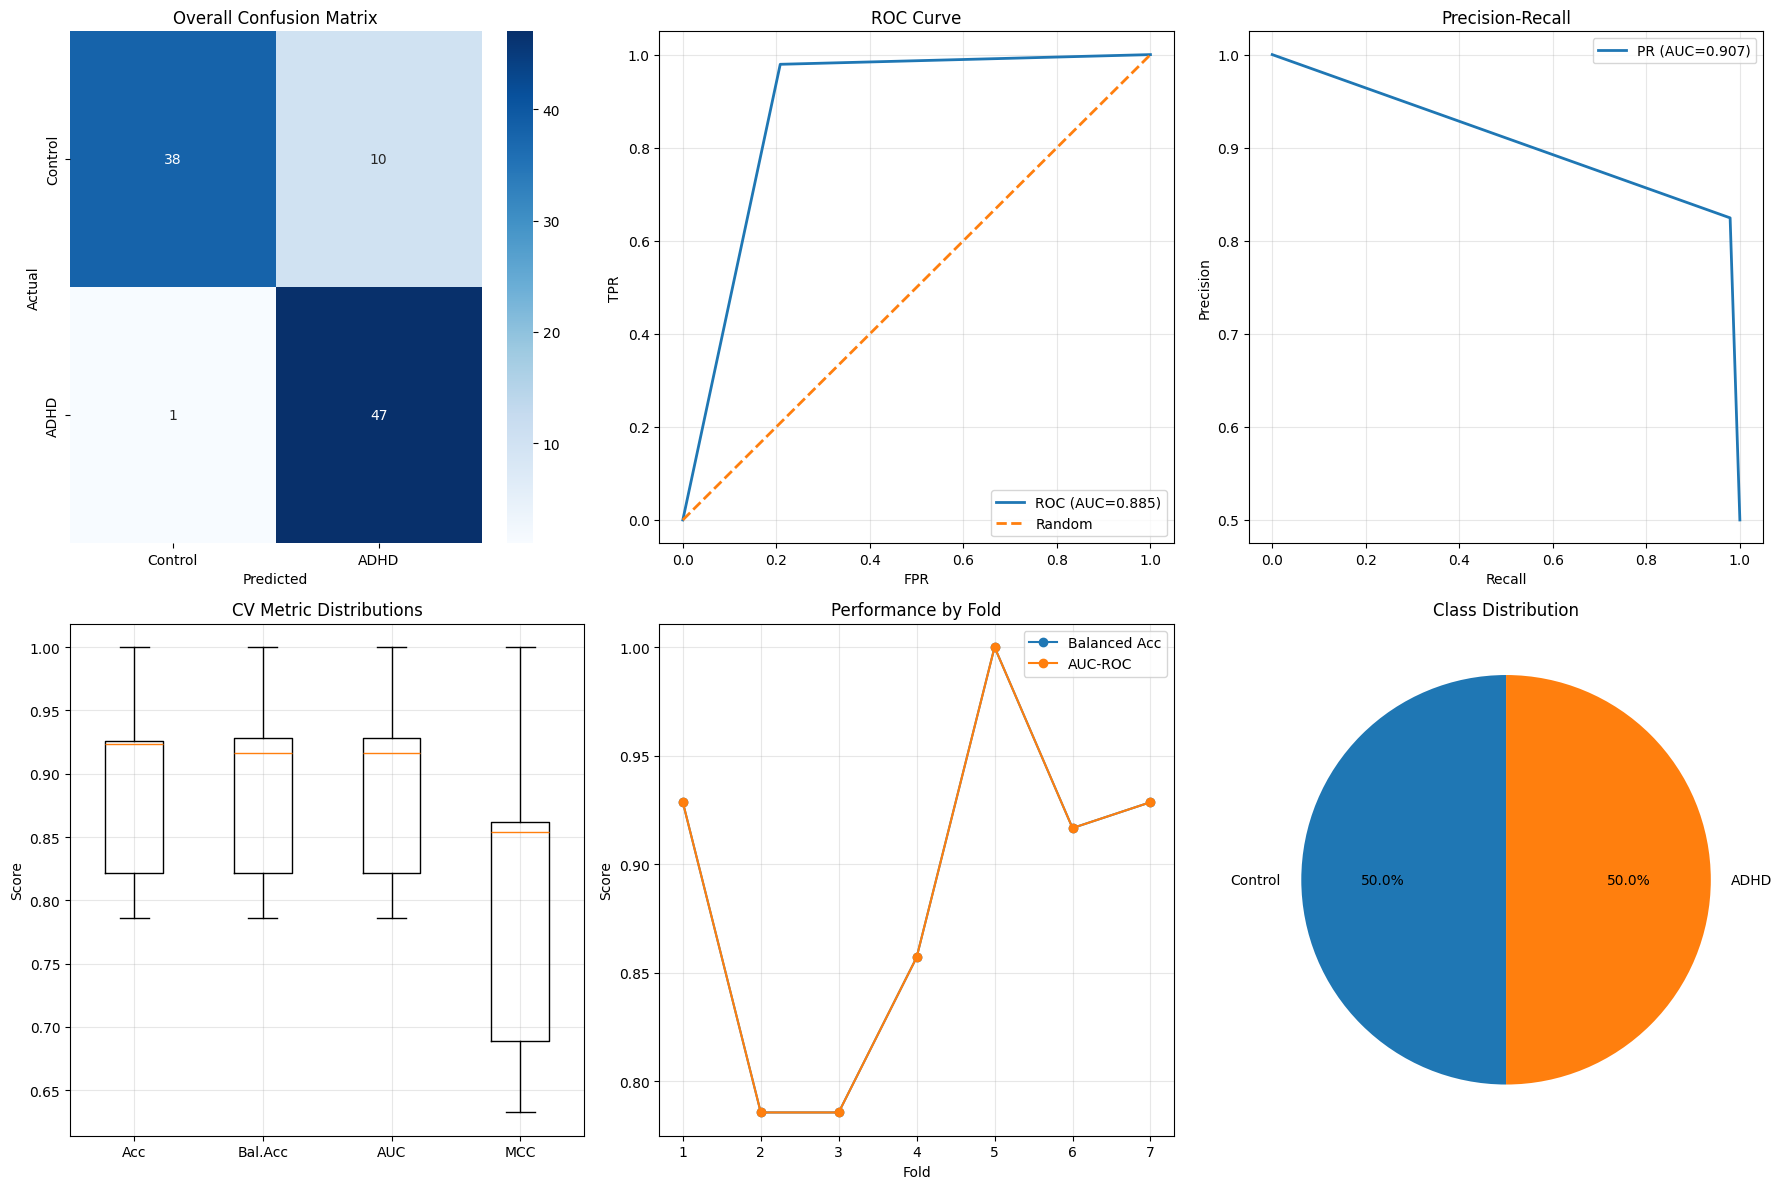


Optuna trials saved to: /content/drive/MyDrive/multivariate_frontal_hmms_n3_f7_ppk_optuna_results.csv

ANALYSIS COMPLETE
Best rho: 0.423473
Best T: 2
Best k_neighbors: 1
Final test balanced accuracy: 0.7981


In [ ]:
"""
PPK-KNN Classification - for Multivariate Data
"""

import numpy as np
import pandas as pd
import optuna
from numpy import pi as PI, exp, power
from numpy.linalg import det, inv
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    roc_curve, auc, precision_recall_curve, roc_auc_score,
    matthews_corrcoef
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# PPK KERNEL FUNCTIONS
def ppk_gaussian_similarity(mu1, Sigma1, mu2, Sigma2, rho=0.5, regularization=1e-6):
    """Compute PPK similarity between two Gaussians"""
    D = mu1.shape[0]
    Sigma1_reg = Sigma1 + regularization * np.eye(D)
    Sigma2_reg = Sigma2 + regularization * np.eye(D)

    try:
        S1 = inv(Sigma1_reg)
        S2 = inv(Sigma2_reg)
        Sigma_combined = inv(rho * S1 + rho * S2)
    except np.linalg.LinAlgError:
        return 1e-10

    mu_combined = rho * (S1 @ mu1 + S2 @ mu2)

    try:
        det_combined = det(Sigma_combined)
        det1 = det(Sigma1_reg)
        det2 = det(Sigma2_reg)

        if det_combined <= 0 or det1 <= 0 or det2 <= 0:
            return 1e-10

        z = power(2 * PI, (1 - 2*rho) * D / 2) * \
            power(det_combined, 1/2) * \
            power(det1, -rho/2) * \
            power(det2, -rho/2)
    except:
        return 1e-10

    q = -rho/2 * (mu1.T @ S1 @ mu1) - \
        rho/2 * (mu2.T @ S2 @ mu2) + \
        1/2 * (mu_combined.T @ Sigma_combined @ mu_combined)

    if not np.isfinite(q) or not np.isfinite(z):
        return 1e-10

    return z * exp(q)


def ppk_kernel(hmm1, hmm2, T=1, rho=0.5):
    """Compute PPK kernel between two HMMs"""
    pi1, A1, mu1, Sigma1 = hmm1['pi'], hmm1['A'], hmm1['mu'], hmm1['Sigma']
    pi2, A2, mu2, Sigma2 = hmm2['pi'], hmm2['A'], hmm2['mu'], hmm2['Sigma']

    M, N = pi1.shape[0], pi2.shape[0]

    Psi = np.zeros((M, N))
    for i in range(M):
        for j in range(N):
            Psi[i, j] = ppk_gaussian_similarity(mu1[i], Sigma1[i], mu2[j], Sigma2[j], rho)

    alpha = np.power(np.outer(pi1, pi2), rho) * Psi

    for t in range(T):
        alpha = A1.T @ alpha @ A2
        alpha = np.power(alpha, rho) * Psi

    return np.sum(alpha)



# DATA LOADING
def load_hmm_from_csv_row(row, n_states, n_components, n_features):
    """
    Load HMM from CSV row -  for multivariate covariance matrices

    Covariance matrices are stored in upper triangular format.
    """
    pi = np.array([row[f'pi_{i}'] for i in range(n_states)])

    A = np.zeros((n_states, n_states))
    for i in range(n_states):
        for j in range(n_states):
            A[i, j] = row[f'A_{i}{j}']

    mu = np.zeros((n_states, n_features))
    Sigma = np.zeros((n_states, n_features, n_features))

    for state in range(n_states):
        weights = [row[f'gmm_weight_{state}_{k}'] for k in range(n_components)]
        best_comp = np.argmax(weights)

        # Load means
        for feat in range(n_features):
            mu[state, feat] = row[f'gmm_mean_{state}_{best_comp}_f{feat}']

        # Load covariance matrix
        for i in range(n_features):
            for j in range(n_features):
                if i <= j:
                    # Upper triangle (including diagonal) - read from CSV
                    col_name = f'gmm_cov_{state}_{best_comp}_f{i}f{j}'
                    Sigma[state, i, j] = row[col_name]
                else:
                    # Lower triangle - use symmetry
                    Sigma[state, i, j] = Sigma[state, j, i]

    return {'pi': pi, 'A': A, 'mu': mu, 'Sigma': Sigma}


def load_data(csv_path, n_states, n_components, n_features=None):
    """Load HMMs and labels from CSV"""
    df = pd.read_csv(csv_path)

    if n_features is None:
        n_features = int(df['n_features'].iloc[0])

    hmms = []
    labels = []

    print(f"Loading HMMs from {csv_path}...")

    for idx, row in df.iterrows():
        hmm = load_hmm_from_csv_row(row, n_states, n_components, n_features)
        hmms.append(hmm)
        labels.append(1 if row['dataset_type'] == 'ADHD' else 0)

    labels = np.array(labels)

    print(f"  Loaded {len(hmms)} subjects")
    print(f"  ADHD: {np.sum(labels==1)}, Control: {np.sum(labels==0)}")
    print(f"  States: {n_states}, Components: {n_components}, Features: {n_features}")

    return hmms, labels



# SIMILARITY MATRIX COMPUTATION
def compute_all_similarities(hmms, T, rho):
    """Compute similarity matrix between all HMM pairs"""
    n_subjects = len(hmms)

    K = np.zeros((n_subjects, n_subjects))

    for i in range(n_subjects):
        for j in range(i, n_subjects):
            K[i, j] = ppk_kernel(hmms[i], hmms[j], T=T, rho=rho)
            K[j, i] = K[i, j]

    # Normalize
    K_normalized = np.zeros_like(K)
    for i in range(n_subjects):
        for j in range(n_subjects):
            denom = np.sqrt(K[i, i] * K[j, j])
            K_normalized[i, j] = K[i, j] / denom if denom > 1e-10 else 0.0

    # Clip to [0, 1]
    K_normalized = np.clip(K_normalized, 0, 1)

    return K_normalized


# CROSS-VALIDATION WITH FOLD TRACKING
def kfold_cross_validation_ppk(hmms_train, y_train, rho, T, k_neighbors,
                               n_splits=5, random_state=42):
    """K-fold cross-validation with detailed fold tracking"""
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # Initialize result arrays
    fold_accuracy = []
    fold_balanced_accuracy = []
    fold_auc_roc = []
    fold_mcc = []
    all_true_labels = []
    all_predictions = []
    all_probabilities = []

    print(f"\n  Running {n_splits}-fold cross-validation...")
    print(f"  Parameters: rho={rho:.6g}, T={T}, k={k_neighbors}")

    # Compute similarity matrix ONCE for all folds
    print(f"  Computing full similarity matrix...")
    n_train = len(hmms_train)
    K_full = np.zeros((n_train, n_train))

    for i in range(n_train):
        for j in range(i, n_train):
            K_full[i, j] = ppk_kernel(hmms_train[i], hmms_train[j], T=T, rho=rho)
            K_full[j, i] = K_full[i, j]

    # Normalize
    K_normalized = np.zeros_like(K_full)
    for i in range(n_train):
        for j in range(n_train):
            denom = np.sqrt(K_full[i, i] * K_full[j, j])
            K_normalized[i, j] = K_full[i, j] / denom if denom > 1e-10 else 0.0

    # Clip and convert to distance
    K_normalized = np.clip(K_normalized, 0, 1)
    D_full = 1 - K_normalized
    np.fill_diagonal(D_full, 0)
    D_full = np.maximum(D_full, 0)

    # cross-validation using precomputed distance matrix
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(hmms_train, y_train)):
        # Extract distance submatrices
        D_train = D_full[np.ix_(train_idx, train_idx)]
        D_val = D_full[np.ix_(val_idx, train_idx)]

        # Train KNN
        knn = KNeighborsClassifier(n_neighbors=k_neighbors, metric='precomputed', weights='distance')
        knn.fit(D_train, y_train[train_idx])

        # Predict
        y_pred = knn.predict(D_val)
        y_proba = knn.predict_proba(D_val)[:, 1]

        # Compute metrics
        acc = accuracy_score(y_train[val_idx], y_pred)
        bal_acc = balanced_accuracy_score(y_train[val_idx], y_pred)
        auc_score = roc_auc_score(y_train[val_idx], y_proba)
        mcc = matthews_corrcoef(y_train[val_idx], y_pred)

        fold_accuracy.append(acc)
        fold_balanced_accuracy.append(bal_acc)
        fold_auc_roc.append(auc_score)
        fold_mcc.append(mcc)

        all_true_labels.extend(y_train[val_idx])
        all_predictions.extend(y_pred)
        all_probabilities.extend(y_proba)

        print(f"    Fold {fold_idx+1}: Acc={acc:.4f}, BalAcc={bal_acc:.4f}, AUC={auc_score:.4f}, MCC={mcc:.4f}")

    return {
        'accuracy': np.array(fold_accuracy),
        'balanced_accuracy': np.array(fold_balanced_accuracy),
        'auc_roc': np.array(fold_auc_roc),
        'mcc': np.array(fold_mcc),
        'true_labels': np.array(all_true_labels),
        'predictions': np.array(all_predictions),
        'probabilities': np.array(all_probabilities)
    }



# PLOTTING FUNCTION
def create_evaluation_plots(fold_results, class_names=['Control', 'ADHD']):
    """Create evaluation plots"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # Overall Confusion Matrix
    overall_cm = confusion_matrix(fold_results['true_labels'], fold_results['predictions'])
    sns.heatmap(overall_cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0,0])
    axes[0,0].set_title('Overall Confusion Matrix')
    axes[0,0].set_xlabel('Predicted')
    axes[0,0].set_ylabel('Actual')

    # ROC Curve
    fpr, tpr, _ = roc_curve(fold_results['true_labels'], fold_results['probabilities'])
    auc_score = auc(fpr, tpr)
    axes[0,1].plot(fpr, tpr, lw=2, label=f'ROC (AUC={auc_score:.3f})')
    axes[0,1].plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random')
    axes[0,1].set_xlabel('FPR')
    axes[0,1].set_ylabel('TPR')
    axes[0,1].set_title('ROC Curve')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(fold_results['true_labels'],
                                                   fold_results['probabilities'])
    pr_auc = auc(recall, precision)
    axes[0,2].plot(recall, precision, lw=2, label=f'PR (AUC={pr_auc:.3f})')
    axes[0,2].set_xlabel('Recall')
    axes[0,2].set_ylabel('Precision')
    axes[0,2].set_title('Precision-Recall')
    axes[0,2].legend()
    axes[0,2].grid(True, alpha=0.3)

    # CV Metric Distributions
    metrics_data = [fold_results['accuracy'], fold_results['balanced_accuracy'],
                    fold_results['auc_roc'], fold_results['mcc']]
    axes[1,0].boxplot(metrics_data, labels=['Acc', 'Bal.Acc', 'AUC', 'MCC'])
    axes[1,0].set_title('CV Metric Distributions')
    axes[1,0].set_ylabel('Score')
    axes[1,0].grid(True, alpha=0.3)

    # Performance by Fold
    folds = np.arange(1, len(fold_results['accuracy']) + 1)
    axes[1,1].plot(folds, fold_results['balanced_accuracy'], 'o-', label='Balanced Acc')
    axes[1,1].plot(folds, fold_results['auc_roc'], 'o-', label='AUC-ROC')
    axes[1,1].set_xlabel('Fold')
    axes[1,1].set_ylabel('Score')
    axes[1,1].set_title('Performance by Fold')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

    # Class Distribution
    class_counts = np.bincount(fold_results['true_labels'])
    axes[1,2].pie(class_counts, labels=class_names, autopct='%1.1f%%', startangle=90)
    axes[1,2].set_title('Class Distribution')

    plt.tight_layout()
    plt.show()



# OPTUNA OPTIMIZATION
def objective(trial, hmms_train, y_train, rho_range, T_range, k_neighbors_range, n_splits):
    """Optuna objective function"""
    rho = trial.suggest_float('rho', rho_range[0], rho_range[1])
    T = trial.suggest_int('T', T_range[0], T_range[1])
    k_neighbors = trial.suggest_int('k_neighbors', k_neighbors_range[0], k_neighbors_range[1], step=2)

    similarity_matrix = compute_all_similarities(hmms_train, T, rho)
    similarity_matrix = np.clip(similarity_matrix, 0, 1)

    distance_matrix = 1 - similarity_matrix
    np.fill_diagonal(distance_matrix, 0)
    distance_matrix = np.maximum(distance_matrix, 0)

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_scores = []

    for train_idx, val_idx in cv.split(hmms_train, y_train):
        D_train = distance_matrix[np.ix_(train_idx, train_idx)]
        D_val = distance_matrix[np.ix_(val_idx, train_idx)]

        knn = KNeighborsClassifier(n_neighbors=k_neighbors, metric='precomputed', weights='distance')
        knn.fit(D_train, y_train[train_idx])

        y_pred = knn.predict(D_val)
        acc = balanced_accuracy_score(y_train[val_idx], y_pred)
        fold_scores.append(acc)

    return np.mean(fold_scores)


def optimize_hyperparameters(hmms_train, y_train, rho_range, T_range, k_neighbors_range,
                            n_trials, n_splits, timeout):
    """Run Optuna optimization"""
    print("\n" + "="*60)
    print("STARTING HYPERPARAMETER OPTIMIZATION")
    print("="*60)
    print(f"  rho range: {rho_range}")
    print(f"  T range: {T_range}")
    print(f"  k_neighbors range: {k_neighbors_range}")
    print(f"  n_trials: {n_trials}")
    print(f"  n_splits: {n_splits}")
    print(f"  timeout: {timeout}s ({timeout/3600:.1f}h)")

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner()
    )

    study.optimize(
        lambda trial: objective(trial, hmms_train, y_train, rho_range, T_range,
                               k_neighbors_range, n_splits),
        n_trials=n_trials,
        timeout=timeout,
        show_progress_bar=True
    )

    print("\n" + "="*60)
    print("OPTIMIZATION COMPLETE")
    print("="*60)
    print(f"Best trial:")
    print(f"  rho: {study.best_params['rho']:.6g}")
    print(f"  T: {study.best_params['T']}")
    print(f"  k_neighbors: {study.best_params['k_neighbors']}")
    print(f"  CV Balanced Accuracy: {study.best_value:.4f}")

    return study



# EVALUATION ON TEST SET
def evaluate_on_test_set(hmms_train, y_train, hmms_test, y_test, best_params):
    """Evaluate best model on test set"""
    print("\n" + "="*60)
    print("EVALUATING ON TEST SET")
    print("="*60)

    rho = best_params['rho']
    T = best_params['T']
    k_neighbors = best_params['k_neighbors']

    n_train = len(hmms_train)
    n_test = len(hmms_test)

    print(f"  Computing kernels (T={T}, rho={rho:.6f})...")
    print(f"    Train size: {n_train}")
    print(f"    Test size: {n_test}")

    # Step 1: Compute all kernels
    print("  Computing train-train kernels...")
    K_train_train = np.zeros((n_train, n_train))
    for i in range(n_train):
        for j in range(i, n_train):
            K_train_train[i, j] = ppk_kernel(hmms_train[i], hmms_train[j], T=T, rho=rho)
            K_train_train[j, i] = K_train_train[i, j]

    print("  Computing test-test kernels (for normalization)...")
    K_test_test = np.zeros(n_test)
    for i in range(n_test):
        K_test_test[i] = ppk_kernel(hmms_test[i], hmms_test[i], T=T, rho=rho)

    print("  Computing test-train kernels...")
    K_test_train = np.zeros((n_test, n_train))
    for i in range(n_test):
        for j in range(n_train):
            K_test_train[i, j] = ppk_kernel(hmms_test[i], hmms_train[j], T=T, rho=rho)

    # Step 2: Normalize kernels
    print("  Normalizing kernels...")

    # Normalize train-train
    K_train_normalized = np.zeros_like(K_train_train)
    for i in range(n_train):
        for j in range(n_train):
            denom = np.sqrt(K_train_train[i, i] * K_train_train[j, j])
            if denom > 1e-10:
                K_train_normalized[i, j] = K_train_train[i, j] / denom
            else:
                K_train_normalized[i, j] = 0.0

    # Normalize test-train
    K_test_train_normalized = np.zeros_like(K_test_train)
    K_train_diag = np.diag(K_train_train)
    for i in range(n_test):
        for j in range(n_train):
            denom = np.sqrt(K_test_test[i] * K_train_diag[j])
            if denom > 1e-10:
                K_test_train_normalized[i, j] = K_test_train[i, j] / denom
            else:
                K_test_train_normalized[i, j] = 0.0

    # Step 3: Clip to valid range
    K_train_normalized = np.clip(K_train_normalized, 0, 1)
    K_test_train_normalized = np.clip(K_test_train_normalized, 0, 1)

    # Step 4: Convert to distances
    D_train = 1 - K_train_normalized
    np.fill_diagonal(D_train, 0)
    D_test = 1 - K_test_train_normalized

    # Step 5: Ensure non-negative
    D_train = np.maximum(D_train, 0)
    D_test = np.maximum(D_test, 0)

    # Debug: Check distance matrix properties
    print(f"\n  Distance matrix diagnostics:")
    print(f"    D_train: shape={D_train.shape}, min={D_train.min():.6f}, max={D_train.max():.6f}, mean={D_train.mean():.6f}")
    print(f"    D_test:  shape={D_test.shape}, min={D_test.min():.6f}, max={D_test.max():.6f}, mean={D_test.mean():.6f}")

    # Step 6: Train and predict
    print("\n  Training KNN and predicting...")
    knn = KNeighborsClassifier(n_neighbors=k_neighbors, metric='precomputed', weights='distance')
    knn.fit(D_train, y_train)

    # Get predictions
    y_pred = knn.predict(D_test)
    y_proba = knn.predict_proba(D_test)[:, 1]

    # Debug: Check prediction distribution
    print(f"  Prediction distribution: {np.bincount(y_pred)}")
    print(f"  Probability range: [{y_proba.min():.4f}, {y_proba.max():.4f}]")

    # Step 7: Compute metrics
    test_accuracy = accuracy_score(y_test, y_pred)
    test_bal_acc = balanced_accuracy_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_proba)
    test_mcc = matthews_corrcoef(y_test, y_pred)
    test_cm = confusion_matrix(y_test, y_pred)

    print(f"\n{'='*60}")
    print("TEST RESULTS")
    print(f"{'='*60}")
    print(f"  Accuracy:           {test_accuracy:.4f}")
    print(f"  Balanced Accuracy:  {test_bal_acc:.4f}")
    print(f"  AUC-ROC:            {test_auc:.4f}")
    print(f"  Matthews Corr:      {test_mcc:.4f}")
    print(f"\nTest Confusion Matrix:")
    print(f"              Control  ADHD")
    print(f"Control       {test_cm[0,0]:<7} {test_cm[0,1]:<7}")
    print(f"ADHD          {test_cm[1,0]:<7} {test_cm[1,1]:<7}")

    return {
        'accuracy': test_accuracy,
        'balanced_accuracy': test_bal_acc,
        'auc_roc': test_auc,
        'mcc': test_mcc,
        'confusion_matrix': test_cm,
        'predictions': y_pred,
        'probabilities': y_proba,
        'y_true': y_test
    }



def run_complete_analysis(csv_path, test_size=0.2, random_state=42,
                         rho_range=(0.1, 0.9), T_range=(1, 7),
                         k_neighbors_range=(1, 9), n_trials=100, n_splits=5,
                         timeout=3600, n_states=3, n_components=3, n_features=None):
    """Run complete PPK-KNN analysis"""
    print("\n" + "="*60)
    print("PPK-KNN CLASSIFICATION WITH OPTUNA")
    print("="*60)

    # Load data
    hmms, labels = load_data(csv_path, n_states, n_components, n_features)

    # Split train/test
    print(f"\nSplitting data (test_size={test_size})...")
    indices = np.arange(len(hmms))
    idx_train, idx_test, y_train, y_test = train_test_split(
        indices, labels, test_size=test_size, random_state=random_state, stratify=labels
    )

    hmms_train = [hmms[i] for i in idx_train]
    hmms_test = [hmms[i] for i in idx_test]

    print(f"  Train: {len(hmms_train)} subjects (ADHD: {np.sum(y_train==1)}, Control: {np.sum(y_train==0)})")
    print(f"  Test:  {len(hmms_test)} subjects (ADHD: {np.sum(y_test==1)}, Control: {np.sum(y_test==0)})")

    # Optimize hyperparameters
    study = optimize_hyperparameters(
        hmms_train, y_train, rho_range, T_range, k_neighbors_range,
        n_trials, n_splits, timeout
    )

    best_params = study.best_params

    # Cross-validation with best parameters
    print("\nCross-validation with best params...")
    fold_results = kfold_cross_validation_ppk(
        hmms_train, y_train,
        best_params['rho'],
        best_params['T'],
        best_params['k_neighbors'],
        n_splits=n_splits,
        random_state=random_state
    )

    print("\n" + "="*60)
    print("CROSS-VALIDATION RESULTS")
    print("="*60)
    print(f"  rho: {best_params['rho']:.6g}")
    print(f"  T: {best_params['T']}")
    print(f"  k_neighbors: {best_params['k_neighbors']}")
    for name, key in [('Accuracy', 'accuracy'), ('Balanced Accuracy', 'balanced_accuracy'),
                      ('AUC-ROC', 'auc_roc'), ('MCC', 'mcc')]:
        vals = fold_results[key]
        print(f"  {name}: {vals.mean():.4f} ± {vals.std():.4f}")

    # Evaluate on test set
    test_results = evaluate_on_test_set(
        hmms_train, y_train, hmms_test, y_test, best_params
    )

    # Create evaluation plots
    print("\nGenerating evaluation plots...")
    create_evaluation_plots(fold_results)

    # Save results
    output_file = csv_path.replace('.csv', '_ppk_optuna_results.csv')
    df_trials = study.trials_dataframe()
    df_trials.to_csv(output_file, index=False)
    print(f"\nOptuna trials saved to: {output_file}")

    return {
        'study': study,
        'best_params': best_params,
        'fold_results': fold_results,
        'test_results': test_results,
        'trials_df': df_trials
    }



if __name__ == "__main__":
    results = run_complete_analysis(
        # csv_path='.../synthetic_hmms_results.csv',
        csv_path='.../NxGx/hmm_results.csv',
        test_size=0.2,
        random_state=42,
        rho_range=(0.1, 1.0),
        T_range=(1, 15),
        k_neighbors_range=(1, 15),
        n_trials=2500,
        n_splits=7,
        timeout=(60 * 60 * 3),
        n_states=3, # 4,5
        n_components=3, #4,5
        n_features=None
    )

    print("\n" + "="*60)
    print("ANALYSIS COMPLETE")
    print("="*60)
    print(f"Best rho: {results['best_params']['rho']:.6g}")
    print(f"Best T: {results['best_params']['T']}")
    print(f"Best k_neighbors: {results['best_params']['k_neighbors']}")
    print(f"Final test balanced accuracy: {results['test_results']['balanced_accuracy']:.4f}")

# Probability Product Kernel - SVM Classification


PPK-SVM CLASSIFICATION WITH OPTUNA
Loading HMMs from /content/drive/MyDrive/multivariate_frontal_hmms_n3_f7.csv...


[I 2025-11-11 16:22:54,485] A new study created in memory with name: no-name-76f0b1ac-4a06-497e-b5a5-6d6fb8fda699


  Loaded 121 subjects
  ADHD: 61, Control: 60
  States: 3, Components: 3, Features: 7

Splitting data (test_size=0.2)...
  Train: 96 subjects (ADHD: 48, Control: 48)
  Test:  25 subjects (ADHD: 13, Control: 12)

STARTING HYPERPARAMETER OPTIMIZATION (SVM)
  rho range: (0.4, 0.9)
  T range: (6, 14)
  gamma range: (0.0001, 0.5)
  C range: (1, 500)
  n_trials: 1500
  n_splits: 7
  timeout: 7200s (2.0h)


  0%|          | 0/1500 [00:00<?, ?it/s]

[I 2025-11-11 16:23:07,510] Trial 0 finished with value: 0.8775510204081634 and parameters: {'rho': 0.5872700594236813, 'T': 14, 'gamma': 0.05100627805979915, 'C': 41.28205343826221}. Best is trial 0 with value: 0.8775510204081634.
[I 2025-11-11 16:23:11,892] Trial 1 finished with value: 0.8469387755102041 and parameters: {'rho': 0.4780093202212183, 'T': 7, 'gamma': 0.0001640021491120233, 'C': 217.66241123453668}. Best is trial 0 with value: 0.8775510204081634.
[I 2025-11-11 16:23:16,081] Trial 2 finished with value: 0.8860544217687075 and parameters: {'rho': 0.7005575058716045, 'T': 12, 'gamma': 0.00011916299962955152, 'C': 414.72250004816334}. Best is trial 2 with value: 0.8860544217687075.
[I 2025-11-11 16:23:21,734] Trial 3 finished with value: 0.8877551020408163 and parameters: {'rho': 0.8162213204002109, 'T': 7, 'gamma': 0.0004705059281907648, 'C': 3.126102910311059}. Best is trial 3 with value: 0.8877551020408163.
[I 2025-11-11 16:23:25,932] Trial 4 finished with value: 0.857142

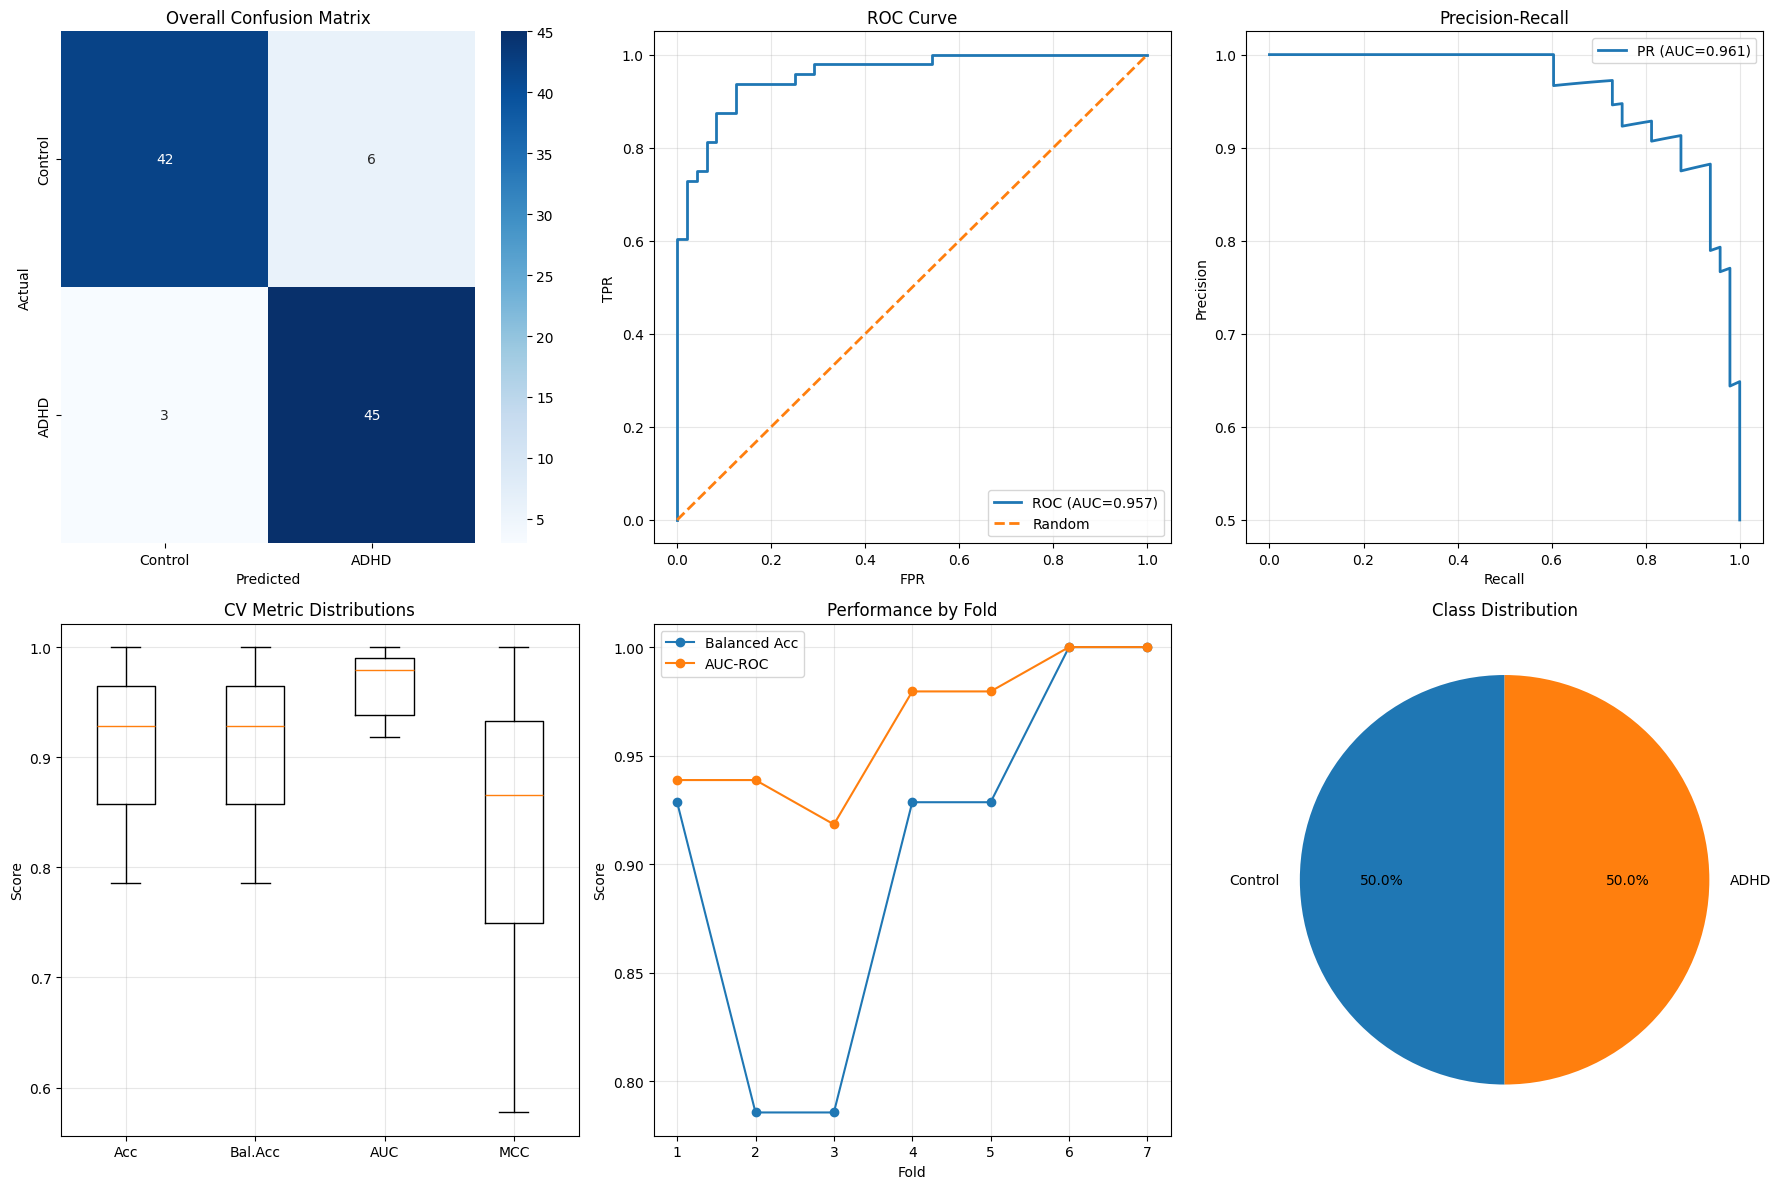


Optuna trials saved to: /content/drive/MyDrive/multivariate_frontal_hmms_n3_f7_ppk_svm_optuna_results.csv

ANALYSIS COMPLETE
Best rho: 0.648448
Best T: 9
Best gamma: 0.00689769
Best C: 4.02252
Final test balanced accuracy: 0.8782


In [ ]:
"""
PPK-SVM Classification with Optuna Optimization - for Multivariate Data
"""

import numpy as np
import pandas as pd
import optuna
from numpy import pi as PI, exp, power
from numpy.linalg import det, inv
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    roc_curve, auc, precision_recall_curve, roc_auc_score,
    matthews_corrcoef
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# PPK KERNEL FUNCTIONS
def ppk_gaussian_similarity(mu1, Sigma1, mu2, Sigma2, rho=0.5, regularization=1e-6):
    """Compute PPK similarity between two Gaussians"""
    D = mu1.shape[0]
    Sigma1_reg = Sigma1 + regularization * np.eye(D)
    Sigma2_reg = Sigma2 + regularization * np.eye(D)

    try:
        S1 = inv(Sigma1_reg)
        S2 = inv(Sigma2_reg)
        Sigma_combined = inv(rho * S1 + rho * S2)
    except np.linalg.LinAlgError:
        return 1e-10

    mu_combined = rho * (S1 @ mu1 + S2 @ mu2)

    try:
        det_combined = det(Sigma_combined)
        det1 = det(Sigma1_reg)
        det2 = det(Sigma2_reg)

        if det_combined <= 0 or det1 <= 0 or det2 <= 0:
            return 1e-10

        z = power(2 * PI, (1 - 2*rho) * D / 2) * \
            power(det_combined, 1/2) * \
            power(det1, -rho/2) * \
            power(det2, -rho/2)
    except:
        return 1e-10

    q = -rho/2 * (mu1.T @ S1 @ mu1) - \
        rho/2 * (mu2.T @ S2 @ mu2) + \
        1/2 * (mu_combined.T @ Sigma_combined @ mu_combined)

    if not np.isfinite(q) or not np.isfinite(z):
        return 1e-10

    return z * exp(q)


def ppk_kernel(hmm1, hmm2, T=1, rho=0.5):
    """Compute PPK kernel between two HMMs"""
    pi1, A1, mu1, Sigma1 = hmm1['pi'], hmm1['A'], hmm1['mu'], hmm1['Sigma']
    pi2, A2, mu2, Sigma2 = hmm2['pi'], hmm2['A'], hmm2['mu'], hmm2['Sigma']

    M, N = pi1.shape[0], pi2.shape[0]

    Psi = np.zeros((M, N))
    for i in range(M):
        for j in range(N):
            Psi[i, j] = ppk_gaussian_similarity(mu1[i], Sigma1[i], mu2[j], Sigma2[j], rho)

    alpha = np.power(np.outer(pi1, pi2), rho) * Psi

    for t in range(T):
        alpha = A1.T @ alpha @ A2
        alpha = np.power(alpha, rho) * Psi

    return np.sum(alpha)



# DATA LOADING
def load_hmm_from_csv_row(row, n_states, n_components, n_features):
    """
    Load HMM from CSV row -  multivariate covariance matrices
    Covariance matrices are stored in upper triangular format
    """
    pi = np.array([row[f'pi_{i}'] for i in range(n_states)])

    A = np.zeros((n_states, n_states))
    for i in range(n_states):
        for j in range(n_states):
            A[i, j] = row[f'A_{i}{j}']

    mu = np.zeros((n_states, n_features))
    Sigma = np.zeros((n_states, n_features, n_features))

    for state in range(n_states):
        weights = [row[f'gmm_weight_{state}_{k}'] for k in range(n_components)]
        best_comp = np.argmax(weights)

        # Load means
        for feat in range(n_features):
            mu[state, feat] = row[f'gmm_mean_{state}_{best_comp}_f{feat}']

        # Load covariance matrix
        for i in range(n_features):
            for j in range(n_features):
                if i <= j:
                    # Upper triangle (including diagonal) - read from CSV
                    col_name = f'gmm_cov_{state}_{best_comp}_f{i}f{j}'
                    Sigma[state, i, j] = row[col_name]
                else:
                    # Lower triangle - use symmetry
                    Sigma[state, i, j] = Sigma[state, j, i]

    return {'pi': pi, 'A': A, 'mu': mu, 'Sigma': Sigma}


def load_data(csv_path, n_states, n_components, n_features=None):
    """Load HMMs and labels from CSV"""
    df = pd.read_csv(csv_path)

    if n_features is None:
        n_features = int(df['n_features'].iloc[0])

    hmms = []
    labels = []

    print(f"Loading HMMs from {csv_path}...")

    for idx, row in df.iterrows():
        hmm = load_hmm_from_csv_row(row, n_states, n_components, n_features)
        hmms.append(hmm)
        labels.append(1 if row['dataset_type'] == 'ADHD' else 0)

    labels = np.array(labels)

    print(f"  Loaded {len(hmms)} subjects")
    print(f"  ADHD: {np.sum(labels==1)}, Control: {np.sum(labels==0)}")
    print(f"  States: {n_states}, Components: {n_components}, Features: {n_features}")

    return hmms, labels



# SIMILARITY MATRIX COMPUTATION
def compute_all_similarities(hmms, T, rho):
    """Compute similarity matrix between all HMM pairs"""
    n_subjects = len(hmms)

    K = np.zeros((n_subjects, n_subjects))

    for i in range(n_subjects):
        for j in range(i, n_subjects):
            K[i, j] = ppk_kernel(hmms[i], hmms[j], T=T, rho=rho)
            K[j, i] = K[i, j]

    # Normalize
    K_normalized = np.zeros_like(K)
    for i in range(n_subjects):
        for j in range(n_subjects):
            denom = np.sqrt(K[i, i] * K[j, j])
            K_normalized[i, j] = K[i, j] / denom if denom > 1e-10 else 0.0

    # Clip to [0, 1]
    K_normalized = np.clip(K_normalized, 0, 1)

    return K_normalized



# CROSS-VALIDATION WITH SVM
def kfold_cross_validation_ppk(hmms_train, y_train, rho, T, gamma, C,
                               n_splits=5, random_state=42):
    """
    K-fold cross-validation with SVM classifier.

    Parameters:
    -----------
    hmms_train : list
        List of HMM dictionaries
    y_train : array
        Training labels
    rho : float
        PPK rho parameter
    T : int
        PPK time steps
    gamma : float
        RBF kernel gamma parameter for SVM
    C : float
        SVM regularization parameter
    n_splits : int
        Number of CV folds
    random_state : int
        Random seed
    """
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # Initialize result arrays
    fold_accuracy = []
    fold_balanced_accuracy = []
    fold_auc_roc = []
    fold_mcc = []
    all_true_labels = []
    all_predictions = []
    all_probabilities = []

    print(f"\n  Running {n_splits}-fold cross-validation...")
    print(f"  Parameters: rho={rho:.6g}, T={T}, gamma={gamma:.6g}, C={C:.6g}")

    # Compute full PPK kernel matrix once
    print(f"  Computing full PPK kernel matrix...")
    n_train = len(hmms_train)
    K_full = np.zeros((n_train, n_train))

    for i in range(n_train):
        for j in range(i, n_train):
            K_full[i, j] = ppk_kernel(hmms_train[i], hmms_train[j], T=T, rho=rho)
            K_full[j, i] = K_full[i, j]

    # Normalize
    K_normalized = np.zeros_like(K_full)
    for i in range(n_train):
        for j in range(n_train):
            denom = np.sqrt(K_full[i, i] * K_full[j, j])
            K_normalized[i, j] = K_full[i, j] / denom if denom > 1e-10 else 0.0

    # Clip to valid range
    K_normalized = np.clip(K_normalized, 0, 1)

    # Now do cross-validation using precomputed kernel
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(hmms_train, y_train)):
        # Extract kernel submatrices
        K_train = K_normalized[np.ix_(train_idx, train_idx)]
        K_val = K_normalized[np.ix_(val_idx, train_idx)]

        # Train SVM with precomputed kernel
        svm = SVC(kernel='precomputed', C=C, gamma=gamma, probability=True, random_state=random_state)
        svm.fit(K_train, y_train[train_idx])

        # Predict
        y_pred = svm.predict(K_val)
        y_proba = svm.predict_proba(K_val)[:, 1]

        # Compute metrics
        acc = accuracy_score(y_train[val_idx], y_pred)
        bal_acc = balanced_accuracy_score(y_train[val_idx], y_pred)
        auc_score = roc_auc_score(y_train[val_idx], y_proba)
        mcc = matthews_corrcoef(y_train[val_idx], y_pred)

        fold_accuracy.append(acc)
        fold_balanced_accuracy.append(bal_acc)
        fold_auc_roc.append(auc_score)
        fold_mcc.append(mcc)

        all_true_labels.extend(y_train[val_idx])
        all_predictions.extend(y_pred)
        all_probabilities.extend(y_proba)

        print(f"    Fold {fold_idx+1}: Acc={acc:.4f}, BalAcc={bal_acc:.4f}, AUC={auc_score:.4f}, MCC={mcc:.4f}")

    return {
        'accuracy': np.array(fold_accuracy),
        'balanced_accuracy': np.array(fold_balanced_accuracy),
        'auc_roc': np.array(fold_auc_roc),
        'mcc': np.array(fold_mcc),
        'true_labels': np.array(all_true_labels),
        'predictions': np.array(all_predictions),
        'probabilities': np.array(all_probabilities)
    }


# PLOTTING FUNCTION
def create_evaluation_plots(fold_results, class_names=['Control', 'ADHD']):
    """
    Create comprehensive evaluation plots
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # Overall Confusion Matrix
    overall_cm = confusion_matrix(fold_results['true_labels'], fold_results['predictions'])
    sns.heatmap(overall_cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0,0])
    axes[0,0].set_title('Overall Confusion Matrix')
    axes[0,0].set_xlabel('Predicted')
    axes[0,0].set_ylabel('Actual')

    # ROC Curve
    fpr, tpr, _ = roc_curve(fold_results['true_labels'], fold_results['probabilities'])
    auc_score = auc(fpr, tpr)
    axes[0,1].plot(fpr, tpr, lw=2, label=f'ROC (AUC={auc_score:.3f})')
    axes[0,1].plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random')
    axes[0,1].set_xlabel('FPR')
    axes[0,1].set_ylabel('TPR')
    axes[0,1].set_title('ROC Curve')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(fold_results['true_labels'],
                                                   fold_results['probabilities'])
    pr_auc = auc(recall, precision)
    axes[0,2].plot(recall, precision, lw=2, label=f'PR (AUC={pr_auc:.3f})')
    axes[0,2].set_xlabel('Recall')
    axes[0,2].set_ylabel('Precision')
    axes[0,2].set_title('Precision-Recall')
    axes[0,2].legend()
    axes[0,2].grid(True, alpha=0.3)

    # CV Metric Distributions
    metrics_data = [fold_results['accuracy'], fold_results['balanced_accuracy'],
                    fold_results['auc_roc'], fold_results['mcc']]
    axes[1,0].boxplot(metrics_data, labels=['Acc', 'Bal.Acc', 'AUC', 'MCC'])
    axes[1,0].set_title('CV Metric Distributions')
    axes[1,0].set_ylabel('Score')
    axes[1,0].grid(True, alpha=0.3)

    # Performance by Fold
    folds = np.arange(1, len(fold_results['accuracy']) + 1)
    axes[1,1].plot(folds, fold_results['balanced_accuracy'], 'o-', label='Balanced Acc')
    axes[1,1].plot(folds, fold_results['auc_roc'], 'o-', label='AUC-ROC')
    axes[1,1].set_xlabel('Fold')
    axes[1,1].set_ylabel('Score')
    axes[1,1].set_title('Performance by Fold')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

    # Class Distribution
    class_counts = np.bincount(fold_results['true_labels'])
    axes[1,2].pie(class_counts, labels=class_names, autopct='%1.1f%%', startangle=90)
    axes[1,2].set_title('Class Distribution')

    plt.tight_layout()
    plt.show()


# OPTUNA OPTIMIZATION FOR SVM
def objective(trial, hmms_train, y_train, rho_range, T_range, gamma_range, C_range, n_splits):
    """
    Optuna objective function for SVM hyperparameter optimization.
    Searches over: rho, T, gamma, C
    """
    # Sample hyperparameters
    rho = trial.suggest_float('rho', rho_range[0], rho_range[1])
    T = trial.suggest_int('T', T_range[0], T_range[1])
    gamma = trial.suggest_float('gamma', gamma_range[0], gamma_range[1], log=True)
    C = trial.suggest_float('C', C_range[0], C_range[1], log=True)

    # Compute PPK similarity matrix
    similarity_matrix = compute_all_similarities(hmms_train, T, rho)
    similarity_matrix = np.clip(similarity_matrix, 0, 1)

    # Cross-validation
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_scores = []

    for train_idx, val_idx in cv.split(hmms_train, y_train):
        K_train = similarity_matrix[np.ix_(train_idx, train_idx)]
        K_val = similarity_matrix[np.ix_(val_idx, train_idx)]

        # Train SVM with precomputed kernel
        svm = SVC(kernel='precomputed', C=C, gamma=gamma, probability=True, random_state=42)
        svm.fit(K_train, y_train[train_idx])

        # Predict and score
        y_pred = svm.predict(K_val)
        bal_acc = balanced_accuracy_score(y_train[val_idx], y_pred)
        fold_scores.append(bal_acc)

    return np.mean(fold_scores)


def optimize_hyperparameters(hmms_train, y_train, rho_range, T_range, gamma_range, C_range,
                            n_trials, n_splits, timeout):
    """Run Optuna optimization for SVM"""
    print("\n" + "="*60)
    print("STARTING HYPERPARAMETER OPTIMIZATION (SVM)")
    print("="*60)
    print(f"  rho range: {rho_range}")
    print(f"  T range: {T_range}")
    print(f"  gamma range: {gamma_range}")
    print(f"  C range: {C_range}")
    print(f"  n_trials: {n_trials}")
    print(f"  n_splits: {n_splits}")
    print(f"  timeout: {timeout}s ({timeout/3600:.1f}h)")

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner()
    )

    study.optimize(
        lambda trial: objective(trial, hmms_train, y_train, rho_range, T_range,
                               gamma_range, C_range, n_splits),
        n_trials=n_trials,
        timeout=timeout,
        show_progress_bar=True
    )

    print("\n" + "="*60)
    print("OPTIMIZATION COMPLETE")
    print("="*60)
    print(f"Best trial:")
    print(f"  rho: {study.best_params['rho']:.6g}")
    print(f"  T: {study.best_params['T']}")
    print(f"  gamma: {study.best_params['gamma']:.6g}")
    print(f"  C: {study.best_params['C']:.6g}")
    print(f"  CV Balanced Accuracy: {study.best_value:.4f}")

    return study


# EVALUATION ON TEST SET
def evaluate_on_test_set(hmms_train, y_train, hmms_test, y_test, best_params):
    """
    Evaluate best SVM model on test set.
    """
    print("\n" + "="*60)
    print("EVALUATING ON TEST SET")
    print("="*60)

    rho = best_params['rho']
    T = best_params['T']
    gamma = best_params['gamma']
    C = best_params['C']

    n_train = len(hmms_train)
    n_test = len(hmms_test)

    print(f"  Computing kernels (T={T}, rho={rho:.6f})...")
    print(f"    Train size: {n_train}")
    print(f"    Test size: {n_test}")

    # Step 1: Compute all kernels (train-train, test-test, test-train)
    print("  Computing train-train kernels...")
    K_train_train = np.zeros((n_train, n_train))
    for i in range(n_train):
        for j in range(i, n_train):
            K_train_train[i, j] = ppk_kernel(hmms_train[i], hmms_train[j], T=T, rho=rho)
            K_train_train[j, i] = K_train_train[i, j]

    print("  Computing test-test kernels (for normalization)...")
    K_test_test = np.zeros(n_test)
    for i in range(n_test):
        K_test_test[i] = ppk_kernel(hmms_test[i], hmms_test[i], T=T, rho=rho)

    print("  Computing test-train kernels...")
    K_test_train = np.zeros((n_test, n_train))
    for i in range(n_test):
        for j in range(n_train):
            K_test_train[i, j] = ppk_kernel(hmms_test[i], hmms_train[j], T=T, rho=rho)

    # Step 2: Normalize kernels
    print("  Normalizing kernels...")

    # Normalize train-train
    K_train_normalized = np.zeros_like(K_train_train)
    for i in range(n_train):
        for j in range(n_train):
            denom = np.sqrt(K_train_train[i, i] * K_train_train[j, j])
            if denom > 1e-10:
                K_train_normalized[i, j] = K_train_train[i, j] / denom
            else:
                K_train_normalized[i, j] = 0.0

    # Normalize test-train
    K_test_train_normalized = np.zeros_like(K_test_train)
    K_train_diag = np.diag(K_train_train)
    for i in range(n_test):
        for j in range(n_train):
            denom = np.sqrt(K_test_test[i] * K_train_diag[j])
            if denom > 1e-10:
                K_test_train_normalized[i, j] = K_test_train[i, j] / denom
            else:
                K_test_train_normalized[i, j] = 0.0

    # Step 3: Clip to valid range
    K_train_normalized = np.clip(K_train_normalized, 0, 1)
    K_test_train_normalized = np.clip(K_test_train_normalized, 0, 1)

    # Debug: Check kernel matrix properties
    print(f"\n  Kernel matrix diagnostics:")
    print(f"    K_train: shape={K_train_normalized.shape}, min={K_train_normalized.min():.6f}, max={K_train_normalized.max():.6f}, mean={K_train_normalized.mean():.6f}")
    print(f"    K_test:  shape={K_test_train_normalized.shape}, min={K_test_train_normalized.min():.6f}, max={K_test_train_normalized.max():.6f}, mean={K_test_train_normalized.mean():.6f}")

    # Step 4: Train and predict
    print("\n  Training SVM and predicting...")
    svm = SVC(kernel='precomputed', C=C, gamma=gamma, probability=True, random_state=42)
    svm.fit(K_train_normalized, y_train)

    # Get predictions
    y_pred = svm.predict(K_test_train_normalized)
    y_proba = svm.predict_proba(K_test_train_normalized)[:, 1]

    # Debug: Check prediction distribution
    print(f"  Prediction distribution: {np.bincount(y_pred)}")
    print(f"  Probability range: [{y_proba.min():.4f}, {y_proba.max():.4f}]")

    # Step 5: Compute metrics
    test_accuracy = accuracy_score(y_test, y_pred)
    test_bal_acc = balanced_accuracy_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_proba)
    test_mcc = matthews_corrcoef(y_test, y_pred)
    test_cm = confusion_matrix(y_test, y_pred)

    print(f"\n{'='*60}")
    print("TEST RESULTS")
    print(f"{'='*60}")
    print(f"  Accuracy:           {test_accuracy:.4f}")
    print(f"  Balanced Accuracy:  {test_bal_acc:.4f}")
    print(f"  AUC-ROC:            {test_auc:.4f}")
    print(f"  Matthews Corr:      {test_mcc:.4f}")
    print(f"\nTest Confusion Matrix:")
    print(f"              Control  ADHD")
    print(f"Control       {test_cm[0,0]:<7} {test_cm[0,1]:<7}")
    print(f"ADHD          {test_cm[1,0]:<7} {test_cm[1,1]:<7}")

    return {
        'accuracy': test_accuracy,
        'balanced_accuracy': test_bal_acc,
        'auc_roc': test_auc,
        'mcc': test_mcc,
        'confusion_matrix': test_cm,
        'predictions': y_pred,
        'probabilities': y_proba,
        'y_true': y_test
    }



def run_complete_analysis(csv_path, test_size=0.2, random_state=42,
                         rho_range=(0.1, 0.9), T_range=(1, 7),
                         gamma_range=(1e-4, 1e1), C_range=(1e-2, 1e3),
                         n_trials=100, n_splits=5, timeout=3600,
                         n_states=3, n_components=3, n_features=None):
    """
    Run complete PPK-SVM analysis with Optuna optimization.
    """
    print("\n" + "="*60)
    print("PPK-SVM CLASSIFICATION WITH OPTUNA")
    print("="*60)

    # Load data
    hmms, labels = load_data(csv_path, n_states, n_components, n_features)

    # Split train/test
    print(f"\nSplitting data (test_size={test_size})...")
    indices = np.arange(len(hmms))
    idx_train, idx_test, y_train, y_test = train_test_split(
        indices, labels, test_size=test_size, random_state=random_state, stratify=labels
    )

    hmms_train = [hmms[i] for i in idx_train]
    hmms_test = [hmms[i] for i in idx_test]

    print(f"  Train: {len(hmms_train)} subjects (ADHD: {np.sum(y_train==1)}, Control: {np.sum(y_train==0)})")
    print(f"  Test:  {len(hmms_test)} subjects (ADHD: {np.sum(y_test==1)}, Control: {np.sum(y_test==0)})")

    # Optimize hyperparameters
    study = optimize_hyperparameters(
        hmms_train, y_train, rho_range, T_range, gamma_range, C_range,
        n_trials, n_splits, timeout
    )

    best_params = study.best_params

    # Cross-validation with best parameters
    print("\nCross-validation with best params...")
    fold_results = kfold_cross_validation_ppk(
        hmms_train, y_train,
        best_params['rho'],
        best_params['T'],
        best_params['gamma'],
        best_params['C'],
        n_splits=n_splits,
        random_state=random_state
    )

    print("\n" + "="*60)
    print("CROSS-VALIDATION RESULTS")
    print("="*60)
    print(f"  rho: {best_params['rho']:.6g}")
    print(f"  T: {best_params['T']}")
    print(f"  gamma: {best_params['gamma']:.6g}")
    print(f"  C: {best_params['C']:.6g}")
    for name, key in [('Accuracy', 'accuracy'), ('Balanced Accuracy', 'balanced_accuracy'),
                      ('AUC-ROC', 'auc_roc'), ('MCC', 'mcc')]:
        vals = fold_results[key]
        print(f"  {name}: {vals.mean():.4f} ± {vals.std():.4f}")

    # Evaluate on test set
    test_results = evaluate_on_test_set(
        hmms_train, y_train, hmms_test, y_test, best_params
    )

    # Create evaluation plots
    print("\nGenerating evaluation plots...")
    create_evaluation_plots(fold_results)

    # Save results
    output_file = csv_path.replace('.csv', '_ppk_svm_optuna_results.csv')
    df_trials = study.trials_dataframe()
    df_trials.to_csv(output_file, index=False)
    print(f"\nOptuna trials saved to: {output_file}")

    return {
        'study': study,
        'best_params': best_params,
        'fold_results': fold_results,
        'test_results': test_results,
        'trials_df': df_trials
    }


if __name__ == "__main__":
    results = run_complete_analysis(
        # csv_path='.../synthetic_hmms_results.csv',
        csv_path='.../NxGx/hmm_results.csv',
        test_size=0.2,
        random_state=42,
        rho_range=(0.4, 0.9),
        T_range=(1, 15),
        gamma_range=(1e-4, 5e-1),
        C_range=(1, 500),
        n_trials=1500,
        n_splits=7,
        timeout=(60 * 60 * 2), # hours
        n_states=3,
        n_components=3,
        n_features=None
    )

    print("\n" + "="*60)
    print("ANALYSIS COMPLETE")
    print("="*60)
    print(f"Best rho: {results['best_params']['rho']:.6g}")
    print(f"Best T: {results['best_params']['T']}")
    print(f"Best gamma: {results['best_params']['gamma']:.6g}")
    print(f"Best C: {results['best_params']['C']:.6g}")
    print(f"Final test balanced accuracy: {results['test_results']['balanced_accuracy']:.4f}")